# Customer Retention Analysis
## Step 1: Data Collection and Exploration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print('libraries loaded  successfully')

libraries loaded  successfully


## Load the Dataset

In [3]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
#shows rows and columns
df.shape

(7043, 21)

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
#column names, non-null counts, data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Summary Statistics

In [7]:
# min, max, mean, std for all numeric columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Check missing values

In [8]:
# count missing values in each column
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
# Checking how many unique values are in the "Churn" column, and their counts
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

## Step 2 : Data Cleaning

In [10]:
# Fixing the TotalCharges column

# Converting TotalCharges to numbers. If a value can't be converted, make it blank (NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many blanks missing values we have now
df['TotalCharges'].isnull().sum()

np.int64(11)

In [11]:
# Fill those blanks with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Confirm it's a proper number column now
df['TotalCharges'].dtype

dtype('float64')

## Step 3: Feature Engineering

In [12]:
# Group customers by tenure (how long they've been a customer)
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72], labels=['New', 'Growing', 'Established', 'Loyal'])

# Check how many customers are in each group
df['tenure_group'].value_counts()

tenure_group
Loyal          2239
New            2175
Established    1594
Growing        1024
Name: count, dtype: int64

In [13]:
# Turn Churn (Yes/No) into numbers (1/0) so we can do math on it
df['Churn_numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Look at both columns side by side
df[['Churn', 'Churn_numeric']].head()

,Churn,Churn_numeric
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


## Step 4: Outliers Detection

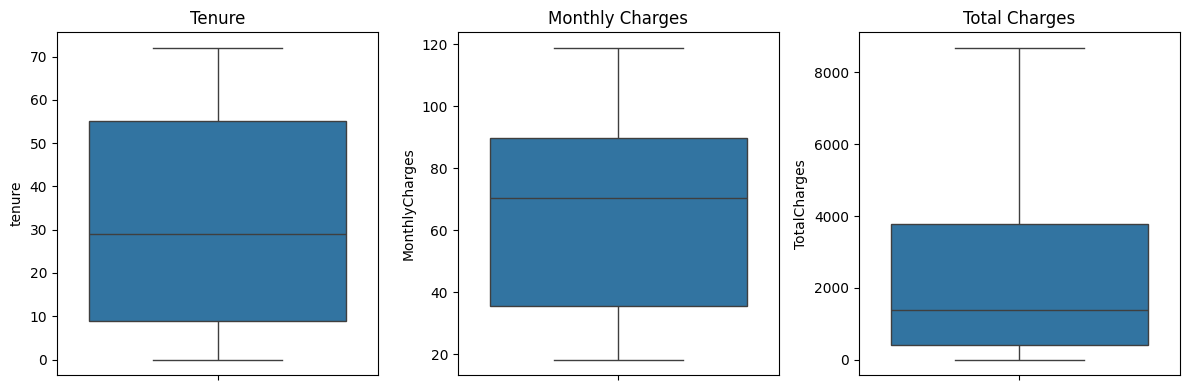

In [14]:
# Create box plots for our 3 numeric columns
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['tenure'])
plt.title('Tenure')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['MonthlyCharges'])
plt.title('Monthly Charges')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['TotalCharges'])
plt.title('Total Charges')

plt.tight_layout() # neatly spaces out the charts so they don't overlap
plt.show()

## Step 5: Exploratory Data Analysis

In [15]:
# 1. Overall churn rate
df['Churn_numeric'].mean()

np.float64(0.2653698707936959)

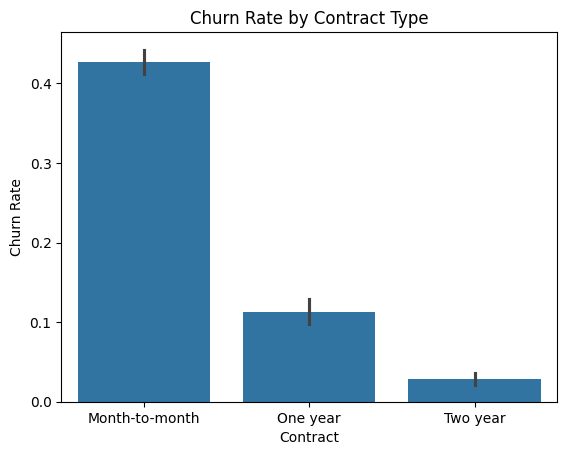

In [16]:
# 2. Does contract type affect churn?
sns.barplot(x='Contract', y='Churn_numeric', data=df)
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.show()

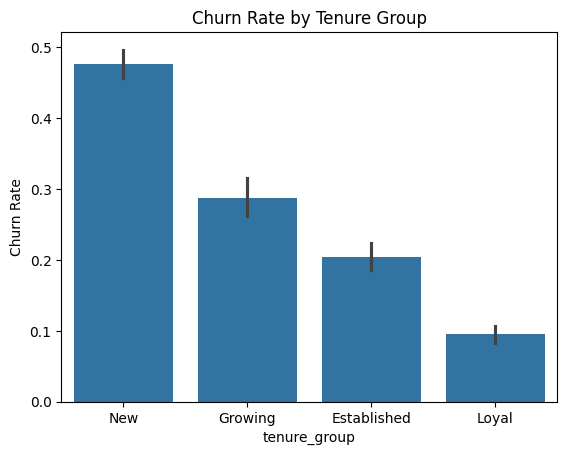

In [17]:
# 3. Does tenure group affect churn?
sns.barplot(x='tenure_group', y='Churn_numeric', data=df)
plt.title('Churn Rate by Tenure Group')
plt.ylabel('Churn Rate')
plt.show()

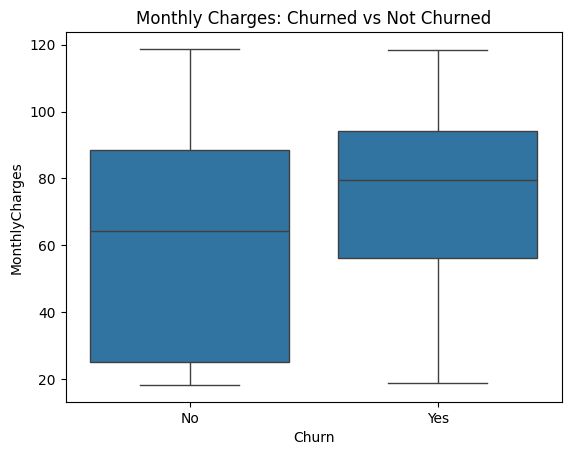

In [18]:
# 4. Do monthly charges differ between churned and non-churned customers?
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges: Churned vs Not Churned')
plt.show()

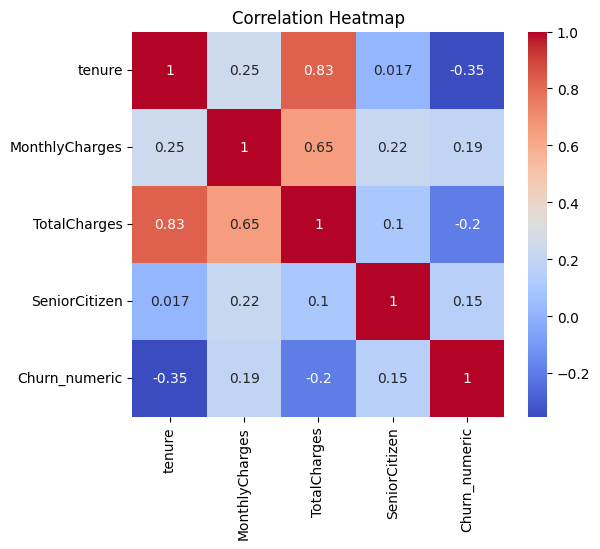

In [19]:
# Select only the numeric columns we care about
numeric_cols = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_numeric']]

# Calculate correlation between all pairs of columns
correlation = numeric_cols.corr()

# Draw the heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

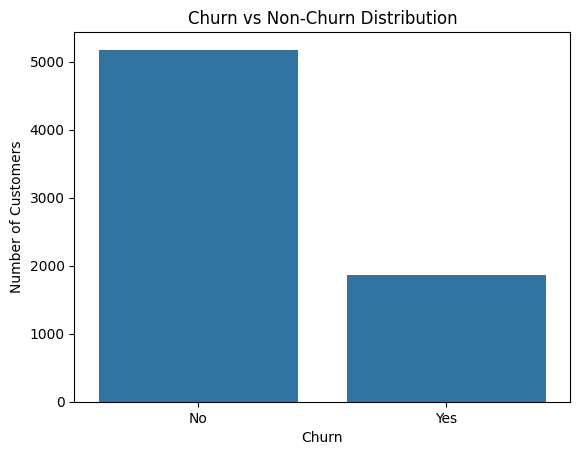

In [20]:
# Count how many customers churned vs stayed
sns.countplot(x='Churn', data=df)
plt.title('Churn vs Non-Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()